---
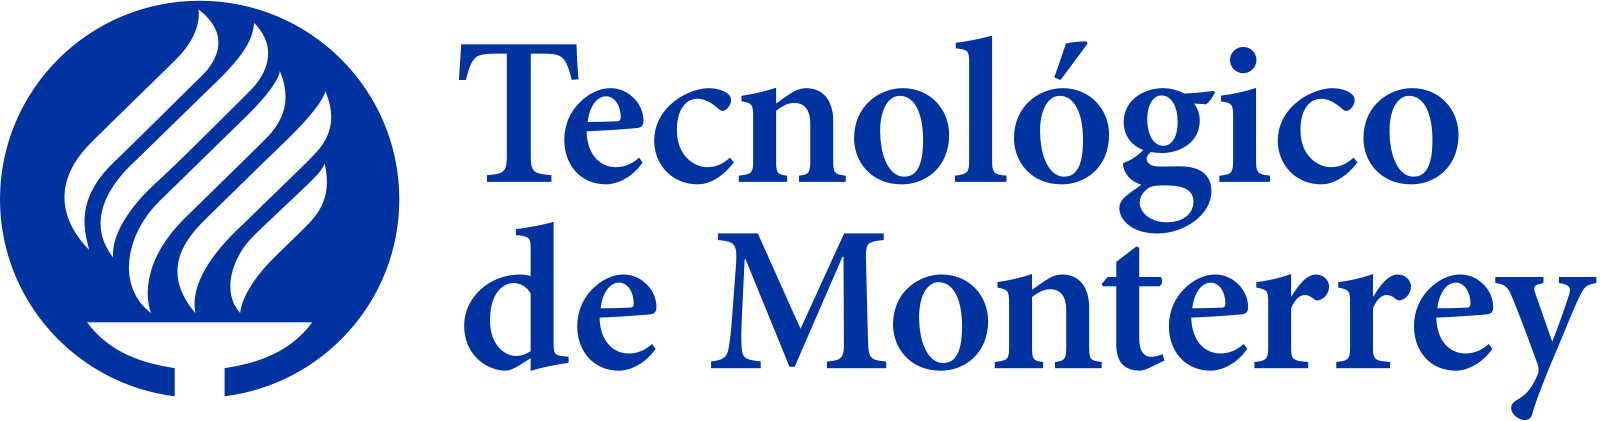

---

**Nombre:** Amilka Daniela Lopez Aguilar

**Matrícula:** A01029277

**Materia:** Inteligencia artificial avanzada para la ciencia de datos

**Docente:** Esteban Castillo Juarez

**Grupo:** 601  

**Fecha:** 19 de agosto de 2026

---

## **Introducción**

El problema a abordar consiste en desarrollar y evaluar un algoritmo K-Nearest Neighbors (KNN) para la clasificación de personas en materia de presencia o ausecia de una enfermedad cardíaca, partiendo de características relacionadas a dicha enfermedad

### **Objetivo**
* Reforzar la teoría de KNN aplicando el algoritmo de clasificación sobre
un conjunto de datos diferente y con una medida de distancia
distinta.
* Practicar la teoría detrás del KNN en el contexto del lenguaje de
programación Python y utilizando la librería de Scikit-learn.

### **Acerca del conjunto de datos**
Se utilizará el conjunto de datos de enfermedades cardíacas de UC Irvine,
el cual contiene 303 muestras, divididas en 242 de entrenamiento y 61 de prueba. Cuenta con 14 variables relacionadas a características clínicas de los individuos.

El objetivo principal es analizar cómo cambia el desempeño del algoritmo KNN al utilizar diferentes medidas de similitud o distancia. Posteriormente, se evaluará el comportamiento del clasificador utilizando diferentes valores de $K$, desde 3 hasta 41, con el propósito de identificar qué combinación de medida de similitud y número de vecinos produce la mayor exactitud.

## **Metodología y Enfoque**

Se conservará la división establecida de los datos entre entrenamiento y prueba (242 : 61), utilizando las muestras de entrenamiento para construir el clasificador y las muestras de prueba para evaluar su desempeño.

La experimentación se realizará en las siguientes etapas:

1. **Carga y preparación de los datos:** se cargarán los conjuntos de entrenamiento y prueba, preprocesando con el archivo anexado (Preprocessing.py), identificando las variables predictoras y la variable objetivo correspondiente al diagnóstico de enfermedad cardíaca.

Este paso ya se completo para efecto de los txts de entrenamiento y prueba**

  a. **Variables:** Edad (numérico), Sexo (binario), Dolor de pecho (numérico, ranking), Presión arterial (numérico), Colesterol en suero (numérico), Glucosa en ayunas (numérico), ECG en reposo (numérico, ranking), Frecuencia cardíaca (numérico), Angina inducida por ejercicio (binario), Depresión del segmento ST inducida por el ejercicio en relación con el reposo (numérico), Segmento ST de ejercicio máximo (numérico), Número de vasos principales (0–3) coloreados por fluorosopía (numérico), Presencia de talasemia (Numérico), Diagnóstico de enfermedad (texto).

  De estas columnas, la última que proporciona el diagnóstico es la que se utilizará como etiqueta de clasificación en el modelo.

2. **Implementación del clasificador KNN y Scikit-learn:** se implementará el algoritmo KNN utilizando las variables para determinar la clasificación de cada individuo a partir de sus vecinos más cercanos.

3. **Comparación de medidas de similitud:** se evaluarán tres medidas de similitud. La primera será la distancia euclidiana, utilizada como referencia; la segunda será la distancia de Manhattan, definida como la suma de los valores absolutos de las diferencias entre las coordenadas de dos vectores.  La tercera medida será una alternativa propuesta para comparar su comportamiento con las dos anteriores. De tal forma que por cada método (KNN manual y Scikit-learn), se tendrán 3 medidas de similitud distintas (6 ejercicios en total).

4. **Variación del valor de $K$:** para cada medida de similitud se probarán valores de $K$ desde 3 hasta 41, con el objetivo de analizar cómo influye el número de vecinos considerados en la precisión del clasificador.

5. **Evaluación del desempeño:** para cada combinación de medida de similitud y valor de $K$ se calculará la exactitud obtenida sobre el conjunto de prueba. Posteriormente, se identificará el valor de $K$ que produzca la mejor exactitud para cada medida.

6. **Análisis gráfico:** se generarán gráficos que permitan visualizar la relación entre el valor de $K$ y la precisión del modelo, así como comparar el rendimiento obtenido utilizando las tres medidas de similitud (Scikit-learn). En el caso de la implementación manual, se propondrán 2 gráficos que mejor expresen el comportamiento del modelo y su desempeño. Esto permitirá observar de manera visual cuál configuración presenta el comportamibiento más exacto.

Finalmente, los resultados obtenidos serán comparados para determinar qué medida de similitud y qué valor de $K$ ofrecen el mejor desempeño para este conjunto de datos. A partir de esta comparación se analizarán los hallazgos y se establecerán las conclusiones correspondientes al proceso de experimentación.

## **KNN - Implementación manual en Python**

### **1. Código de preparación de archivos**

In [92]:
#Importar librerías matemáticas y de manipulación
import numpy as np
import codecs
from google.colab import drive

"""
Instancia de Google drive
"""
drive.mount('/content/KNN')
base_path = "/content/"

"""
Leer los archivos de entrenamiento y prueba proporcionados
"""
training_file = "/content/training.txt"
test_file = "/content/test.txt"

print("Data de entrenamiento:")
training_data = np.loadtxt(training_file, delimiter=",", dtype=str)
print(training_data)

print("Data de prueba:")
test_data = np.loadtxt(test_file, delimiter=",", dtype=str)
print(test_data)

'''
La siguiente modificación está pensanda para mejorar el accuracy del modelo
Verificación de la distribución de los datos
'''

from collections import Counter

# Separar características (X) y etiquetas (y)
trainingData = training_data[:, :-1]
trainingLabels = training_data[:, -1]

testData = test_data[:, :-1]
testLabels = test_data[:, -1]


print("Distribución de clases en entrenamiento:")
print(Counter(trainingLabels))

print("\nDistribución de clases en prueba:")
print(Counter(testLabels))

Drive already mounted at /content/KNN; to attempt to forcibly remount, call drive.mount("/content/KNN", force_remount=True).
Data de entrenamiento:
[['58.0' '1.0' '2.0' ... '0.0' '3.0' 'Present']
 ['76.0' '0.0' '3.0' ... '0.0' '3.0' 'Absence']
 ['68.0' '0.0' '3.0' ... '0.0' '3.0' 'Absence']
 ...
 ['47.0' '1.0' '4.0' ... '1.0' '3.0' 'Present']
 ['62.0' '0.0' '4.0' ... '0.0' '3.0' 'Absence']
 ['52.0' '1.0' '3.0' ... '0.0' '3.0' 'Absence']]
Data de prueba:
[['51.0' '1.0' '3.0' '100.0' '222.0' '0.0' '0.0' '143.0' '1.0' '1.2'
  '2.0' '0.0' '3.0' 'Absence']
 ['65.0' '0.0' '3.0' '160.0' '360.0' '0.0' '2.0' '151.0' '0.0' '0.8'
  '1.0' '0.0' '3.0' 'Absence']
 ['38.0' '1.0' '1.0' '120.0' '231.0' '0.0' '0.0' '182.0' '1.0' '3.8'
  '2.0' '0.0' '7.0' 'Present']
 ['50.0' '1.0' '3.0' '129.0' '196.0' '0.0' '0.0' '163.0' '0.0' '0.0'
  '1.0' '0.0' '3.0' 'Absence']
 ['56.0' '0.0' '4.0' '134.0' '409.0' '0.0' '2.0' '150.0' '1.0' '1.9'
  '2.0' '2.0' '7.0' 'Present']
 ['52.0' '0.0' '3.0' '136.0' '196.0' '0.0'

## **2. Función de similitud**

Anteriormente se presentó el uso de la distancia Euclidiana y Manhattan para la resolución del ejercicio. Adicionalmente, se propone la distancia Chebyshev, la cual expresa la mayor diferencia entre dos vectores a lo largo de cualquier dimensión de coordenadas (Grootendorst, s. f.)

| Distancia | Fórmula | Característica |
|---|---|---|
| Euclidiana | √Σ(xᵢ - yᵢ)² | Distancia en línea recta |
| Manhattan | Σ\|xᵢ - yᵢ\| | Suma de diferencias absolutas |
| Chebyshev | max\|xᵢ - yᵢ\| | Toma la mayor diferencia |




In [93]:
#Importar librería matemática
import math
"""
Función en python que calcula similitud entre dos vectores (Distancia Euclidania)
Input: lista (list1)
Input: lista (list2)
Output: float (similitud)
"""
def euclideanDistance(list1, list2):
  sumList=0
  for x, y in zip(list1, list2):
    sumList=sumList+((y - x) ** 2)
  return math.sqrt(sumList)

"""
Función en python que calcula similitud entre dos vectores (Manhattan)
Input: lista (list1)
Input: lista (list2)
Output: float (similitud)
"""
def manhattanDistance(list1, list2):
  sumList=0
  for x, y in zip(list1, list2):
    sumList= math.fabs(y - x)
  return (sumList)

"""
Función en python que calcula similitud entre dos vectores (Chebyshev)
Input: lista (list1)
Input: lista (list2)
Output: float (similitud)
"""
def chebyshevDistance(list1, list2):
    sumList = 0
    for x, y in zip(list1, list2):
        sumList = max(sumList, math.fabs(y - x))
    return sumList

## **3. Código de implementación del clasificador para KNN**



In [94]:
#Importar itemgetter para manipulación iterable
from operator import itemgetter
#Importar variable estadística (moda)
from statistics import mode
"""
Define una función de Python que, dado un vector de prueba,
calcule los K vecinos más cercanos del conjunto de entrenamiento
y asigne la etiqueta mayoritaria al vector de prueba.
Input: lista - testList -- conjunto de prueba
Input: lista de lista (trainingLists) -- conjunto de entrenamiento
Input: list (trainingLabels) -- etiquetas para clasificar
Input: int (k) -- vecinos
Input: función (distanceFunction) -- función de similitud a utilizar
Output: texto (prediction label) -- etiqueta predictiva
"""
def classify(testList, trainingLists, trainingLabels, k, distanceFunction):
  distance=[]
#Para cada lista en el conjunto de datos:
  for trainingList, label in zip(trainingLists,trainingLabels):
#Calcular la distancia entre la lista de prueba y la lista de entrenamiento actual.
    value=distanceFunction(testList, trainingList)
    distance.append((value,label))
#Ordenar distancias (ASC)
  distance.sort(key=itemgetter(0))
  votelabels=[]
#vecinos a utilizar entorno a la lista de prueba
  for x in distance[:k]:
    votelabels.append(x[1])
#Encontrar la clase mayoritaria entre estos elementos y devuelve la clase mayoritaria como predicción.
  return mode(votelabels)

## **4. Implementación Práctica de KNN en Python**

In [95]:
# Importar librería de manipulación de archivos
import codecs

training = []
test = []
trainingLabels = []
testLabels = []

# Cargar conjunto de entrenamiento
print("Load training samples")

with codecs.open(base_path + "training.txt", "r", "UTF-8") as file:
    for line in file:
        elements = line.rstrip('\n').split(",")
        training.append([float(x) for x in elements[:-1]])
        trainingLabels.append(elements[-1]) # ahora la última columna es la etiqueta, la 14


# Cargar conjunto de prueba
print("Load test samples")

with codecs.open(base_path + "test.txt", "r", "UTF-8") as file:
    for line in file:
        elements = line.rstrip('\n').split(",")
        test.append([float(x) for x in elements[:-1]])
        testLabels.append(elements[-1])

'''
Se elimina el barajar de los datos ya que no representa una mejora en precisión
# Barajar training
indices = np.random.permutation(len(training))

training = np.array(training)[indices].tolist()
trainingLabels = np.array(trainingLabels)[indices].tolist()
'''

'''
La siguiente estandarización de valores forma parte de las mejoras a
implementar, ya que las características se reportan en escalas distintas y
pueden afectar el peso que se les da en el algoritmo de knn
'''

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
training = scaler.fit_transform(training).tolist()
test = scaler.transform(test).tolist()

# Guardamos las 3 medidas propuestas en un diccionario -- acceso desde un mismo KNN
distanceMeasures = {
    "Euclidean": euclideanDistance,
    "Manhattan": manhattanDistance,
    "Chebyshev": chebyshevDistance
}


# Guardar resultados para después poder consultar y evaluar
results = {}

#k y diccionarios iterables

for distanceName, distanceFunction in distanceMeasures.items():

    results[distanceName] = {}

    print("\n" + distanceName + " Distance") # segmentar print para que sea más fácil de encontrar

    for k in range(3, 42):

        correctPredictions = 0
        TotalPredictions = 0

        print("K =", k)
        print("Predictions vs. True Labels:")

        # Clasificamos cada muestra de prueba
        for x, y in zip(test, testLabels):

            TotalPredictions += 1

            predicted = classify(x, training, trainingLabels, k, distanceFunction)

            # print de prediccions vs valor reals
            print("Predicted: " + str(predicted) + " realValue: " + str(y))

            if predicted == y:
                correctPredictions += 1

        # Calculamos la precisión
        accuracy = correctPredictions / TotalPredictions * 100

        # Guardamos la precisión
        results[distanceName][k] = accuracy

        print(
            "K =", k, "Model accuracy:", accuracy)

# K que produce la mayor precisión por medida de similitud
bestResults = {}

for distanceName in results:

    bestK = max(
        results[distanceName],
        key=results[distanceName].get
    )

    bestAccuracy = results[distanceName][bestK]

    bestResults[distanceName] = (bestK, bestAccuracy)

    print(
        distanceName,
        "Mejor K para cada medida de similitud: ",
        bestK,
        "| Accuracy:",
        bestAccuracy,
        "%"
    )


# Mejor k
bestDistance = None
bestK = None
bestAccuracy = 0

for distanceName in results:

    for k in results[distanceName]:

        accuracy = results[distanceName][k]

        if accuracy > bestAccuracy:
            bestAccuracy = accuracy
            bestDistance = distanceName
            bestK = k

print("Mejor K entre las 3 medidas de similitud")
print("Distancia:", bestDistance)
print("k:", bestK)
print("Accuracy:", bestAccuracy, "%")

Streaming output truncated to the last 5000 lines.
Predictions vs. True Labels:
Predicted: Absence realValue: Absence
Predicted: Absence realValue: Absence
Predicted: Present realValue: Present
Predicted: Absence realValue: Absence
Predicted: Present realValue: Present
Predicted: Absence realValue: Absence
Predicted: Absence realValue: Present
Predicted: Absence realValue: Absence
Predicted: Present realValue: Absence
Predicted: Absence realValue: Absence
Predicted: Present realValue: Present
Predicted: Absence realValue: Absence
Predicted: Absence realValue: Absence
Predicted: Present realValue: Absence
Predicted: Absence realValue: Present
Predicted: Absence realValue: Present
Predicted: Present realValue: Present
Predicted: Absence realValue: Present
Predicted: Absence realValue: Absence
Predicted: Absence realValue: Absence
Predicted: Absence realValue: Absence
Predicted: Absence realValue: Present
Predicted: Present realValue: Absence
Predicted: Absence realValue: Absence
Predicte

## **5. Comportamiento del modelo**

In [96]:
import pandas as pd
import plotly.express as px

'''
Gráfico de barras que muestra el número de aciertos (x = y o predicted value = real value) cuando usamos la mejor K para cada distancia
'''
correct_by_distance = {}

for distanceName, distanceFunction in distanceMeasures.items():

    # Retomamos el mejor K previamente calculado
    bestK = max(results[distanceName], key=results[distanceName].get)
    correctPredictions = 0

    # Contar aciertos usando el mejor k
    for x, y in zip(test, testLabels):

        predicted = classify(
            x,
            training,
            trainingLabels,
            bestK,
            distanceFunction
        )

        if predicted == y:
            correctPredictions += 1

    correct_by_distance[distanceName] = correctPredictions


# Crear dataframe para el gráfico -> https://es.stackoverflow.com/questions/513740/crear-dataframe-a-partir-de-una-lista
dataframe = pd.DataFrame({
    "Distance": list(correct_by_distance.keys()),
    "Correct Predictions": list(correct_by_distance.values())
})


# Generar gráfico de barras
fig = px.bar(
    dataframe,
    x="Distance",
    y="Correct Predictions",
    color="Distance",
    title=" # Predicciones correctas por medida de similitud usando su mejor K",
    labels={
        "Distance": "Medida de Similitud",
        "Correct Predictions": "# predicciones correctas"
    }
)

fig.show()

data = []

# Generar gráfico box para ver la distribución de la exactitud
for distanceName in results:
    for k, accuracy in results[distanceName].items():
        data.append({
            "Distance": distanceName,
            "K": k,
            "Accuracy": accuracy
        })

dataframe = pd.DataFrame(data)

fig = px.box(
    dataframe,
    x="Distance",
    y="Accuracy",
    color="Distance",
    labels={
        "Distance": "Distancia",
        "Accuracy": "Accuracy (%)"
    },
    title="Distribución de Accuracy por distancia"
)

fig.show()

## **6. Observaciones Clave** (previo a las modificaciones y mejoras)

* Manhattan y un K Bajo: La implementación manual logró su mejor precisión (77.05%) utilizando la distancia Manhattan y un valor de K relativamente bajo (K=7). Este fue el rendimiento superior entre las métricas probadas manualmente.

* Variabilidad en K Óptimo y Estabilidad de Métricas: El valor óptimo de K mostró variaciones significativas entre las distancias (K=7 para Euclidean y Manhattan, K=41 para Chebyshev). La distancia Manhattan demostró ser más estable en su rendimiento a través de los distintos valores de K, a diferencia de las fluctuaciones observadas con Euclidean y Chebyshev.

## **7. Implementación con Scikit-learn**


In [97]:
#Cargar librerías específicas
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np

#Cargar archivos
training=[]
trainingLabels=[]
test=[]
testLabels=[]

print("Load training samples")

with codecs.open(base_path+"training.txt","r","UTF-8") as file:
  for line in file:
    elements=(line.rstrip('\n')).split(",")
    training.append([float(x) for x in elements[:-1]])
    trainingLabels.append(elements[-1]) # ahora la última columna es la etiqueta, la 14


print("Load test samples")

with codecs.open(base_path+"test.txt","r","UTF-8") as file:
  for line in file:
    elements=(line.rstrip('\n')).split(",")
    test.append([float(x) for x in elements[:-1]])
    testLabels.append(elements[-1])
'''
Se elimina el barajar de los datos ya que no representa una mejora en precisión
# Barajar training manteniendo las etiquetas correspondientes
indices = np.random.permutation(len(training))

training = np.array(training)[indices]
trainingLabels = np.array(trainingLabels)[indices]
'''

'''
La siguiente estandarización de valores forma parte de las mejoras a
implementar, ya que las características se reportan en escalas distintas y
pueden afectar el peso que se les da en el algoritmo de knn
'''

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
training = scaler.fit_transform(training)
test = scaler.transform(test)

# KNN de scikit-learn
print("Apply the KNN approach over test samples on scikit-learn")

# Las medidas a probar
distanceMeasures = {
    "Euclidean": "euclidean",
    "Manhattan": "manhattan",
    "Chebyshev": "chebyshev"
}

# Guardar resultados
results = {}

for distanceName, distanceMetric in distanceMeasures.items():

    results[distanceName] = {}

    print("\nDistance:", distanceName)

    # K de 3 a 41
    for k in range(3, 42):

        print("\nK =", k)

        # Crear el modelo KNN
        knn = KNeighborsClassifier(
            n_neighbors=k,
            metric=distanceMetric
            # Quitamos weights = distance, ya que no mejoró la precisión del modelo
        )

        # Fit del modelo
        knn.fit(training, trainingLabels)

        # Hacer predicciones
        predictions = knn.predict(test)

        # Predicción vs valor real
        print("Predictions vs. True Labels:")

        for i in range(len(predictions)):
            print("Predicted: " + str(predictions[i]) + " realValue: " + str(testLabels[i]))

        # Desempeño
        accuracy = accuracy_score(testLabels, predictions) * 100

        # Guardamos la precisión
        results[distanceName][k] = accuracy

        print("K =", k, "Model accuracy:", accuracy)

# Mejor K y accuracy por cada distancia
print("Mejor K por distancia")

for distanceName in results:

    bestK = max(results[distanceName], key=results[distanceName].get)
    bestAccuracy = results[distanceName][bestK]

    print(
        distanceName,
        "Best K:", bestK,
        "| Accuracy:", accuracy, "%"
    )

bestDistance = None
bestK = None
bestAccuracy = 0

for distanceName in results:
    for k, accuracy in results[distanceName].items():

        if accuracy > bestAccuracy:
            bestAccuracy = accuracy
            bestDistance = distanceName
            bestK = k

print("Mejor K entre las 3 distancias")
print(
    "Distance:", bestDistance,
    "| Best K:", bestK,
    "| Accuracy:", accuracy, "%"
)

Streaming output truncated to the last 5000 lines.
Predicted: Present realValue: Present
Predicted: Present realValue: Absence
Predicted: Absence realValue: Absence
Predicted: Present realValue: Absence
Predicted: Absence realValue: Present
Predicted: Present realValue: Present
Predicted: Absence realValue: Present
Predicted: Present realValue: Present
Predicted: Absence realValue: Absence
Predicted: Absence realValue: Absence
Predicted: Absence realValue: Absence
Predicted: Present realValue: Present
Predicted: Absence realValue: Absence
Predicted: Absence realValue: Absence
Predicted: Absence realValue: Present
Predicted: Absence realValue: Absence
Predicted: Present realValue: Present
Predicted: Absence realValue: Absence
Predicted: Present realValue: Present
Predicted: Present realValue: Absence
Predicted: Absence realValue: Absence
Predicted: Present realValue: Present
Predicted: Absence realValue: Absence
Predicted: Absence realValue: Absence
Predicted: Absence realValue: Absence

## **8. Comportamiento del modelo**

In [98]:
# Gráfico de predicciones incorrectas vs correctas tipo pie chart

for distanceName in results:

    # Obtener el mejor K
    bestK = max(
        results[distanceName],
        key=results[distanceName].get
    )

    # Crear modelo
    knn = KNeighborsClassifier(
        n_neighbors=bestK,
        metric=distanceMeasures[distanceName]
    )

    # Entrenar
    knn.fit(training, trainingLabels)

    # Predecir
    predictions = knn.predict(test)

    # Contar aciertos
    correctPredictions = sum(
        predictions[i] == testLabels[i]
        for i in range(len(predictions))
    )

    # Contar errores
    incorrectPredictions = len(testLabels) - correctPredictions

    # DataFrame
    dataframe = pd.DataFrame({
        "Resultado": ["Correctas", "Incorrectas"],
        "Cantidad": [
            correctPredictions,
            incorrectPredictions
        ]
    })

    # Gráfico
    fig = px.pie(
        dataframe,
        names="Resultado",
        values="Cantidad",
        title="Predicciones - " + distanceName +
              " (K = " + str(bestK) + ")"
    )

    fig.show()

# Heatmap para visualizar la mejor k por medida de distancia

    # Convertir results a DataFrame -> Transpuesto porque con K como diferentes valores debe ser una columna distinta
dataframe = pd.DataFrame(results).T

# Crear heatmap (plotly.express.imshow —  6.8.0 Documentation, s. f.)
data = []

for distanceName in results:
    accuracyAverage = sum(results[distanceName].values()) / len(results[distanceName])

    data.append({
        "Distance": distanceName,
        "Accuracy": accuracyAverage
    })

dataframe = pd.DataFrame(data)

# Heatmap
fig = px.imshow(
    [dataframe["Accuracy"]],
    x=dataframe["Distance"],
    y=["Accuracy"],
    color_continuous_scale="Blues",
    title="Accuracy promedio por medida de distancia"
)

fig.show()

'''Precisión según K para cada medida'''
# Convertir results a DataFrame
dataframe = pd.DataFrame(results)

# Pasar K de índice a columna -> uso de reset index por el uso de melt para visualizar distancias hacia "abajo" en un df
dataframe = dataframe.reset_index()
dataframe = dataframe.rename(columns={"index": "K"})

# Convertir a formato largo
dataframe = dataframe.melt(
    id_vars="K",
    var_name="Distance",
    value_name="Accuracy"
)

# Gráfico
fig = px.line(
    dataframe,
    x="K",
    y="Accuracy",
    color="Distance",
    markers=True,
    title="Accuracy de KNN según el valor de K",
    labels={
        "K": "Valor de K",
        "Accuracy": "Accuracy (%)",
        "Distance": "Medida de distancia"
    }
)

fig.show()

'''
Comparación del rendimiento
'''

data = []

for distanceName in results:

    bestK = max(
        results[distanceName],
        key=results[distanceName].get
    )

    bestAccuracy = results[distanceName][bestK]

    data.append({
        "Distance": distanceName,
        "Accuracy": bestAccuracy,
        "K": bestK
    })

dataframe = pd.DataFrame(data)

fig = px.bar(
    dataframe,
    x="Distance",
    y="Accuracy",
    color="Distance",
    text="Accuracy",
    title="Comparación del rendimiento de KNN por medida de similitud",
    labels={
        "Distance": "Medida de similitud",
        "Accuracy": "Mejor Accuracy (%)"
    }
)

fig.show()

## **9. Observaciones Clave** (previo a mejoras y cambios)

* Manhattan Lidera en Scikit-learn: En la implementación de Scikit-learn, la distancia Manhattan fue la que alcanzó el mejor rendimiento con un 70.49% de precisión con K=14, superando a las distancias Euclidean y Chebyshev.

* K Óptimo Específico por Distancia: Al igual que en la implementación manual, cada métrica de distancia en Scikit-learn tuvo un valor óptimo de K diferente para maximizar la precisión (K=4 para Euclidean, K=14 para Manhattan, K=39 para Chebyshev), destacando la necesidad de ajustar este hiperparámetro para cada caso.

* Diferencias Notables con la Implementación Manual: El mejor rendimiento obtenido con Scikit-learn (70.49%) fue inferior al alcanzado con la implementación manual (77.05%). Esta discrepancia, junto con los diferentes valores de K y las métricas que produjeron estos máximos, sugiere diferencias internas en cómo cada implementación maneja aspectos como el desempate o la selección de vecinos.

## **10. Resultados** (Previos a cambios y mejoras)

En esta sección se presentan los resultados obtenidos durante la implementación y evaluación del algoritmo K-Nearest Neighbors (KNN). El experimento se realizó en dos etapas principales. Primero, se implementó el algoritmo KNN directamente en Python, realizando de manera manual el cálculo de las distancias y la selección de los vecinos más cercanos. Posteriormente, se utilizó la implementación de KNN proporcionada por la biblioteca **Scikit-learn**, con el objetivo de comparar los resultados y analizar el comportamiento del algoritmo.

### a. Resultados con distancia Euclidiana

Para la distancia Euclidiana se evaluaron valores de $K$ entre 3 y 41.

Los resultados mostraron que la precisión varió aproximadamente entre 40.98% y 68.85%. El mejor resultado se obtuvo con:

**$K$  = 7**
**Accuracy = 68.85%**

También se obtuvieron resultados de 68.85% con algunos otros valores de $K$, como 4 y 6, mientras que valores pequeños como $K$ = 3 alcanzaron una precisión de 63.93%.

Esto indica que, para este conjunto de datos, utilizar un número relativamente pequeño de vecinos permitió obtener mejores resultados utilizando la distancia Euclidiana.

### b. Resultados con distancia Manhattan

Posteriormente, se evaluó la distancia Manhattan utilizando los mismos valores de $K$$K$.

En este caso, los resultados fueron superiores a los obtenidos con la distancia Euclidiana. La mayoría de los valores de $K$$K$ alcanzaron una precisión de 77.05%.

El mejor resultado fue obtenido utilizando:

**k = 7**
**Accuracy = 77.05%**

Este fue el mayor porcentaje de precisión obtenido durante las pruebas realizadas con la implementación de KNN en Python.

Es importante observar que, en este caso, un valor pequeño de $K$ produjo el mejor resultado. A diferencia de la distancia Euclidiana en sus picos, aumentar considerablemente el número de vecinos no produjo una mejora significativa en la precisión.

Mejor resultado con Manhattan:

**k = 7 → Accuracy = 77.05%**

### c. Resultados con distancia Chebyshev

Finalmente, se evaluó la distancia Chebyshev con los mismos valores de $K$.

Los resultados obtenidos con esta medida de distancia fueron generalmente inferiores a los obtenidos con Manhattan y Euclidiana. La precisión se encontró aproximadamente entre 39.34% y 67.21%.

El mejor resultado se obtuvo con:

**k = 41**
**Accuracy = 67.21%**

Aunque algunos valores de $K$ produjeron resultados relativamente cercanos a los obtenidos con Euclidean, la distancia Chebyshev no logró superar el desempeño de las otras dos medidas.

Mejor resultado con Chebyshev:

**k = 41 → Accuracy = 67.21%**

### d. Comparación de las medidas de distancia

Al comparar los mejores resultados obtenidos para cada medida de distancia, se obtuvo la siguiente tabla:

| Medida de distancia | Mejor valor de k | Accuracy |
|---|---:|---:|
| Euclidean | 7 | 68.85% |
| Manhattan | 7 | **77.06%** |
| Chebyshev | 41 | 67.21% |

A partir de estos resultados, la combinación que presentó el mejor desempeño fue **Manhattan Distance con k = 7**, alcanzando una precisión de **77.06%**.

La distancia Manhattan superó a Euclidean por aproximadamente 8.4 puntos porcentuales y a Chebyshev por aproximadamente 9.85 puntos porcentuales.

Esto demuestra que la elección de la medida de distancia puede influir directamente en las predicciones realizadas por KNN. No existe una medida de distancia que necesariamente sea la mejor para todos los conjuntos de datos, por lo que es necesario experimentar con diferentes alternativas.

### e. Influencia del valor de K

Otro de los aspectos analizados fue el efecto del número de vecinos  sobre la precisión del modelo.

El valor de $K$ determina cuántos vecinos se consideran para realizar la clasificación de una nueva muestra. Un valor pequeño de $K$ hace que la predicción dependa de un número reducido de muestras cercanas, mientras que un valor mayor considera una cantidad más amplia de vecinos.

Los resultados obtenidos muestran que la relación entre $K$ y precisón no es lineal. Aumentar el número de vecinos no significa necesariamente obtener una mayor precisión.

Por ejemplo:

- Con **Euclidean**, el mejor resultado fue obtenido con $K$ = 7.
- Con **Manhattan**, el mejor resultado fue obtenido con $K$ = 7.
- Con **Chebyshev**, el mejor resultado fue obtenido con $K$ = 41.

Por lo tanto, el valor óptimo de $K$ depende de la medida de distancia utilizada y de las características del conjunto de datos.


### f. Mejor configuración encontrada en scikit-learn

### g. Resultados con Scikit-learn

Posteriormente, se implementó KNN utilizando **Scikit-learn** y se realizaron las mismas pruebas con valores de $k$ entre 3 y 41 y las tres medidas de distancia. Los resultados mostraron que, para **Euclidean**, la mejor configuración fue **$k = 4$**, con una precisión de **68.85%**; para **Manhattan**, el mejor resultado fue con **$k = 14$**, alcanzando **70.49%**; mientras que para **Chebyshev**, el mejor resultado fue **$k = 39$**, con **68.85%**. Por lo tanto, el mejor resultado general obtenido mediante Scikit-learn fue **Manhattan con $k = 14$ y una precisión de 70.49%**.

Al compararlo con la implementación manual, se observa que esta había obtenido como mejores configuraciones **Manhattan con $k = 7$ (77.05%)**, **Euclidean con $k = 7$ (68.85%)** y **Chebyshev con $k = 41$ (67.21%)**. Es decir, ambas implementaciones alcanzaron diferentes precisiones máximas (**77.05% para la manual y 70.49% para Scikit-learn**), y los valores de $k$ y la medida de distancia que produjeron dicho resultado también fueron diferentes.

Las diferencias entre ambas implementaciones pueden deberse a la forma en que se realizan internamente operaciones como el cálculo y ordenamiento de las distancias, la selección de los $k$ vecinos y el manejo de empates entre clases o entre distancias. Esto es especialmente relevante porque el conjunto de prueba contiene **61 muestras**, por lo que una sola predicción incorrecta o correcta representa aproximadamente **1.64 puntos porcentuales** de precisión. Esto se debe a que la precisión es una tasa calculada como el número de predicciones correctas dividido entre el total de muestras.

Por esta razón, pequeñas diferencias en las predicciones pueden producir cambios visibles en los resultados. Además, los resultados muestran que no necesariamente existe una única combinación óptima: en Scikit-learn, **Manhattan** alcanzó **70.49% con $k = 14$**, mientras que en la implementación manual **Manhattan** alcanzó **77.05% con $k = 7$**.

## **11. Mejoras y exploración**

Con el objetivo de obtener un **accuracy más alto**, se implementaron y evaluaron diferentes mejoras en el modelo KNN. Estas modificaciones permitieron analizar cómo distintos aspectos del preprocesamiento y de la configuración del algoritmo afectan el desempeño del clasificador.

Entre las mejoras y configuraciones exploradas se encuentran:

1. **Estandarización de la escala de los datos.**
2. **Barajado de los datos** para evitar que el orden de las muestras influya en el entrenamiento.
3. **Balanceo de las clases**, procurando que no exista una presencia desproporcionada de datos de una clase, como *Absence* frente a *Presence*, que pueda sesgar los resultados.
4. **Prueba de distintos valores de $k$**, como parte de los requisitos del ejercicio.
5. **Prueba de distintas medidas de distancia**, incluyendo Euclidean, Manhattan y Chebyshev.
6. **Ponderación de los vecinos según su distancia**, dando mayor importancia a los vecinos más cercanos.

### **11.1. Impacto de la estandarización**

Una de las mejoras que produjo un cambio más significativo en el desempeño fue la **estandarización de los datos**. Esta transformación permite que las diferentes variables se encuentren en escalas comparables, evitando que aquellas con valores numéricamente mayores tengan una influencia desproporcionada en el cálculo de las distancias.

#### **Implementación manual de KNN**

- **Antes de estandarizar:** la mejor precisión fue de **77.05%**, utilizando **Manhattan con $k = 7$**.
- **Después de estandarizar:** la mejor precisión alcanzó **85.25%**, utilizando **Euclidean con $k = 14$**.
- **Mejora:** aproximadamente **8.20 puntos porcentuales**.

#### **Implementación de KNN con Scikit-learn**

- **Antes de estandarizar:** la mejor precisión fue de **70.49%**, utilizando **Manhattan con $k = 14$**.
- **Después de estandarizar:** la mejor precisión aumentó a **88.52%**, utilizando **Manhattan con $k = 22$**.
- **Mejora:** aproximadamente **18.03 puntos porcentuales**.

Estos resultados muestran que la estandarización tuvo un impacto considerable en ambas implementaciones, aunque el efecto fue aún mayor en la implementación realizada con **Scikit-learn**.

### **11.2. Balance de las clases**

También se revisó la distribución de las clases **Presence** y **Absence**. Se observó que el conjunto de entrenamiento presenta un balance relativamente adecuado entre ambas clases, mientras que el conjunto de prueba se encuentra **ligeramente desbalanceado**.

Este aspecto es importante porque un conjunto de datos desbalanceado puede hacer que el *accuracy* no represente completamente el desempeño del modelo. Por ejemplo, si una clase tiene una mayor cantidad de muestras, un clasificador podría obtener una precisión aparentemente alta simplemente por favorecer dicha clase.

Por esta razón, además del *accuracy*, se analizará posteriormente la **matriz de confusión** y se introducirán otras métricas de desempeño que permitan determinar si existe algún sesgo hacia alguna de las clases.

### **11.3. Ponderación de los vecinos según la distancia**

Otra mejora explorada consistió en asignar un mayor peso a los vecinos más cercanos. En lugar de considerar que todos los vecinos tienen la misma importancia, los votos se ponderan de acuerdo con la distancia entre cada vecino y la muestra que se desea clasificar.

Una forma de realizarlo es mediante la **inversa de la distancia**, de manera que un vecino muy cercano tenga una influencia mayor que uno que se encuentre más alejado.

Esta estrategia permite que el modelo sea más sensible a la **estructura local de los datos**. Los vecinos más alejados, aunque se encuentren dentro de los $k$ seleccionados, pueden ser menos representativos de la muestra que se está clasificando o incluso introducir ruido. Al reducir su influencia, el clasificador puede enfocarse principalmente en las muestras más cercanas.


### **11.4. Efecto de la ponderación y el barajado en Scikit-learn**

Sin embargo, al analizar específicamente el efecto individual de cada modificación en la implementación de **Scikit-learn**, se observó que la introducción de pesos basados en la distancia **no produjo un cambio significativo en la precisión del modelo**.

Esto indica que, para este conjunto de datos, la cercanía de los vecinos no parece ser un factor determinante para modificar la clasificación cuando se utiliza esta implementación.

De manera similar, el **barajado de los datos** tampoco produjo una mejora en el desempeño. Incluso se observó una ligera disminución de la precisión en el caso de Scikit-learn. Esto sugiere que el orden original de las muestras no estaba generando un sesgo significativo en los resultados y que, en este caso particular, barajar los datos no aporta una ventaja en términos de precisión.

### **11.5. Conclusiones de las mejoras**

En general, los experimentos muestran que **no todas las mejoras tienen el mismo impacto** sobre el desempeño del modelo. La estandarización fue la modificación que produjo el efecto más significativo, aumentando la precisión máxima de **77.05% a 85.25%** en la implementación manual y de **70.49% a 88.52%** en Scikit-learn.

Por otro lado, el balance de las clases es un aspecto que debe considerarse al interpretar los resultados, especialmente porque el conjunto de prueba presenta un ligero desbalance. Por esta razón, el análisis mediante la **matriz de confusión y métricas adicionales** será necesario para determinar si el modelo realmente tiene un buen desempeño en ambas clases.

Finalmente, tanto la ponderación de los vecinos como el barajado de los datos mostraron un impacto limitado en la precisión de Scikit-learn. Esto demuestra que algunas modificaciones que teóricamente pueden mejorar KNN no necesariamente producen una mejora en todos los conjuntos de datos, por lo que su utilidad debe comprobarse experimentalmente.

## **12. Conclusiones**

A partir de los resultados obtenidos, se puede concluir que la medida de distancia y el valor de k influyen directamente en el desempeño del algoritmo KNN, sin embargo, no necesariamente lineal. En este experimento, la distancia Manhattan obtuvo el mejor resultado, seguida de Euclidean y Chebyshev. Se demuestra que aumentar el número de vecinos no necesariamente mejora la precisión, ya que el mejor valor de k fue diferente para cada medida.

La implementación manual permitió comprender el funcionamiento interno de KNN, principalmente el cálculo de las distancias, la selección de los vecinos más cercanos y la asignación de la clase mediante votación. Por otro lado, Scikit-learn simplificó considerablemente la implementación, al proporcionar una versión optimizada del algoritmo que permite probar diferentes configuraciones de manera más sencilla.

Uno de los hallazgos más significativos fue el **impacto de la estandarización de los datos**. Esta mejora en el preprocesamiento resultó en un aumento sustancial de la precisión en ambas implementaciones:

- **Implementación manual:** la precisión máxima se elevó del **77.05%** (con Manhattan, $k = 7$, antes de estandarizar) al **85.25%** (con Euclidean, $k = 14$, después de estandarizar).
- **Scikit-learn:** la precisión máxima mejoró del **70.49%** (con Manhattan, $k = 14$, antes de estandarizar) al **88.52%** (con Manhattan, $k = 22$, después de estandarizar).

Esto demuestra que la correcta escala de las características es fundamental para los algoritmos basados en distancia, ya que permite que todas las variables contribuyan de manera más equitativa al cálculo de la similitud.

Después de la estandarización, la implementación de Scikit-learn demostró el mejor rendimiento general, alcanzando un notable **88.52% de precisión con la distancia Manhattan y $k = 22$**.

Finalmente, la comparación entre ambas implementaciones permitió observar tanto el funcionamiento del algoritmo como las ventajas de utilizar una biblioteca especializada. Aunque se encontró una configuración con el mejor desempeño, su accuracy indica que el modelo presenta todavía limitaciones para clasificar correctamente los datos. Por ello, sería conveniente explorar otras configuraciones o algoritmos de clasificación y evaluar si se está utilizando el más óptimo.

## **Referencias**

Grootendorst, M. (s. f.). 9 Distance measures in data science - Maarten Grootendorst. https://www.maartengrootendorst.com/blog/distances/

KNeighborsClassifier. (s. f.). Scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

plotly.express.imshow —  6.8.0 documentation. (s. f.). https://plotly.com/python-api-reference/generated/plotly.express.imshow.html

StandardScaler. (s. f.). Scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
